<a href="https://colab.research.google.com/github/nik021001/FedEx-Logistics-EDA-Capstone/blob/main/FedEx_Logistics_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## # FedEx Logistics Performance Analysis — Exploratory Data Analysis

**Project Name:** FedEx Logistics Performance Analysis (Supply Chain Shipment & Pricing Data)

**Project Type:** Exploratory Data Analysis (EDA)

**GitHub Link:** [Add after Step 12 — pushing to GitHub]

**Dataset:** Supply Chain Health Commodity Shipment & Pricing Data — 10,324 shipment records across 33 columns, covering purchase orders, vendors, INCO terms, shipment modes, product details, delivery dates, weights, and freight costs.

## Project Summary

FedEx Logistics moves medical supplies — like HIV medicines and test kits — to many countries around the world. This dataset has information on more than 10,000 of these shipments. It tells us things like which vendor sent the shipment, how it was shipped, when it was supposed to arrive, when it actually arrived, how heavy it was, and how much it cost to ship.

The goal of this project is to study this data carefully and find useful patterns in it. In a such a big supply chain ,  small problems can add up fast. For example, a shipping method that looks cheap on paper might actually cause a lot of delays. Some vendors might promise good delivery terms but not actually deliver on time. Some countries might face more delays than others because of customs issues or poor roads. The only way to find these problems is by studying the data closely, which is what this project does.

We start by cleaning the data. Some columns, like Weight and Freight Cost, had text mixed with numbers (like "Weight Captured Separately" instead of an actual number), so we had to fix those and turn them into proper numbers. We also fixed the date columns so we could calculate things like delays. After cleaning, we created some new columns to help with analysis: how many days late (or early) each shipment was, whether it was on time or not, how much lead time the vendor was given, and the shipping cost per kilogram.

After that, we explored the data in three stages. First, we looked at one column at a time — for example, which countries get the most shipments, or how shipping costs are spread out. Second, we compared two columns at a time — for example, does shipping by air cost more than by truck, or do some countries have more delays than others. Third, we looked at three or more things together — for example, whether a specific country AND a specific shipping method together cause more delays than either one alone.

For every chart in this notebook, we explain three things: why we chose that chart, what it shows, and why it matters for FedEx's business — whether it points to a way to save money, a delivery problem to fix, or a vendor that needs attention. The goal is not just to make charts, but to give the FedEx team clear, useful information they can actually act on — like which shipping methods to use more, which countries need backup plans, and where costs can be cut without hurting delivery speed.

By the end of this project, we have a clear picture of what's working well in FedEx's shipping process and what's costing them time and money — which directly supports FedEx's goal of delivering faster and cheaper for their customers.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 40)

In [98]:
df = pd.read_csv('/content/SCMS_Delivery_History_Dataset.csv')
print('shape of the dataset:',df.shape)
df.head()

shape of the dataset: (10324, 33)


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [100]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,10324.0,NaN,NaN,NaN,51098.968229,31944.332496,1.0,12795.75,57540.5,83648.25,86823.0
Project Code,10324,142,116-ZA-T30,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PQ #,10324,1237,Pre-PQ Process,2681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PO / SO #,10324,6233,SCMS-199289,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASN/DN #,10324,7030,ASN-19166,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,10324,43,South Africa,1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Managed By,10324,4,PMO - US,10265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfill Via,10324,2,From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vendor INCO Term,10324,8,N/A - From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipment Mode,9964,4,Air,6113,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Dosage                       1736
Shipment Mode                 360
Line Item Insurance (USD)     287
dtype: int64


In [102]:
# Convert messy text columns to proper numbers (non-numeric text becomes NaN)
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

print('Missing Weight after cleaning:', df['Weight (Kilograms)'].isnull().sum())
print('Missing Freight Cost after cleaning:', df['Freight Cost (USD)'].isnull().sum())

Missing Weight after cleaning: 3952
Missing Freight Cost after cleaning: 4126


In [103]:
# Parse all date columns properly
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date',
             'Delivered to Client Date', 'Delivery Recorded Date']

for c in date_cols:
    df[c]=pd.to_datetime(df[c],errors='coerce')
df[date_cols].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   PQ First Sent to Client Date  7643 non-null   datetime64[ns]
 1   PO Sent to Vendor Date        4592 non-null   datetime64[ns]
 2   Scheduled Delivery Date       10324 non-null  datetime64[ns]
 3   Delivered to Client Date      10324 non-null  datetime64[ns]
 4   Delivery Recorded Date        10324 non-null  datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 403.4 KB


In [104]:
# Handle remaining missing values
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')
df['Dosage'] = df['Dosage'].fillna('Not Applicable')
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(0)

print('Remaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Weight (Kilograms)              3952
Freight Cost (USD)              4126
dtype: int64


In [105]:
# Delivery delay in days (positive = late, negative = early)
df['Delivery Delay (Days)'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days

# On-time flag
df['On Time Status'] = np.where(df['Delivery Delay (Days)'] <= 0, 'On Time', 'Delayed')

# Vendor lead time: PO sent to vendor -> scheduled delivery
df['Vendor Lead Time (Days)'] = (df['Scheduled Delivery Date'] - df['PO Sent to Vendor Date']).dt.days

# Freight cost per kilogram (efficiency measure)
df['Freight Cost per KG'] = df['Freight Cost (USD)'] / df['Weight (Kilograms)']
df['Freight Cost per KG'] = df['Freight Cost per KG'].replace([np.inf, -np.inf], np.nan)

df[['Delivery Delay (Days)', 'On Time Status', 'Vendor Lead Time (Days)', 'Freight Cost per KG']].describe(include='all')

,Delivery Delay (Days),On Time Status,Vendor Lead Time (Days),Freight Cost per KG
count,10324.000000,10324,4592.000000,6174.000000
unique,NaN,2,NaN,NaN
top,NaN,On Time,NaN,NaN
freq,NaN,9138,NaN,NaN
mean,-6.023537,NaN,105.742596,38.930123
std,27.233640,NaN,78.027811,581.780481
min,-372.000000,NaN,-160.000000,0.000539
25%,-3.000000,NaN,52.000000,3.048539
50%,0.000000,NaN,92.000000,7.263902
75%,0.000000,NaN,142.000000,14.920496


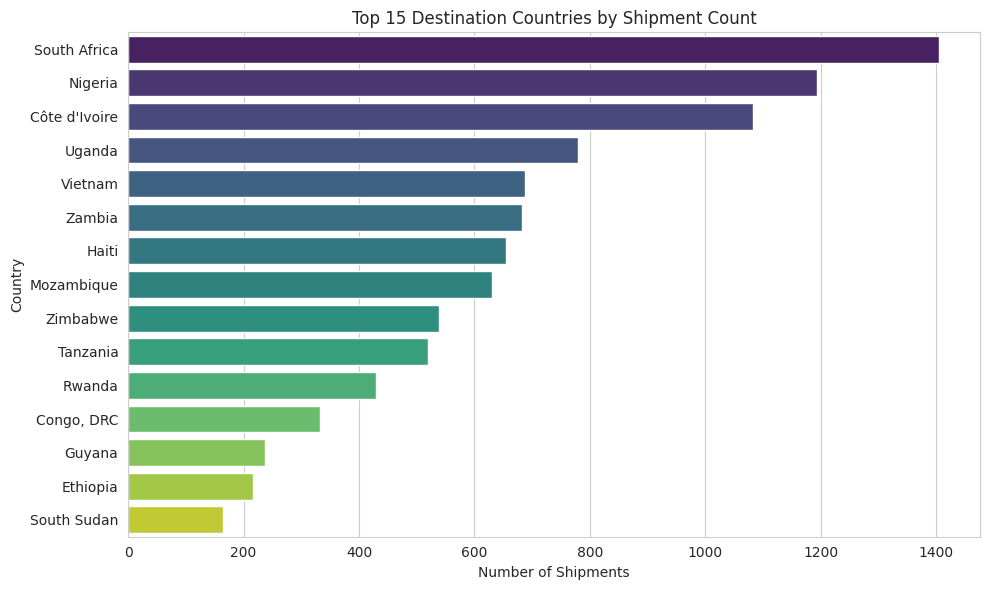

In [106]:
top_countries = df['Country'].value_counts().nlargest(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 15 Destination Countries by Shipment Count')
plt.xlabel('Number of Shipments')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Why:** Bar chart ranks which countries receive the most shipments.

**Insight:** A handful of countries dominate shipment volume.

**Business Impact:** These high-volume countries should be prioritized for dedicated logistics contracts and negotiated freight rates.

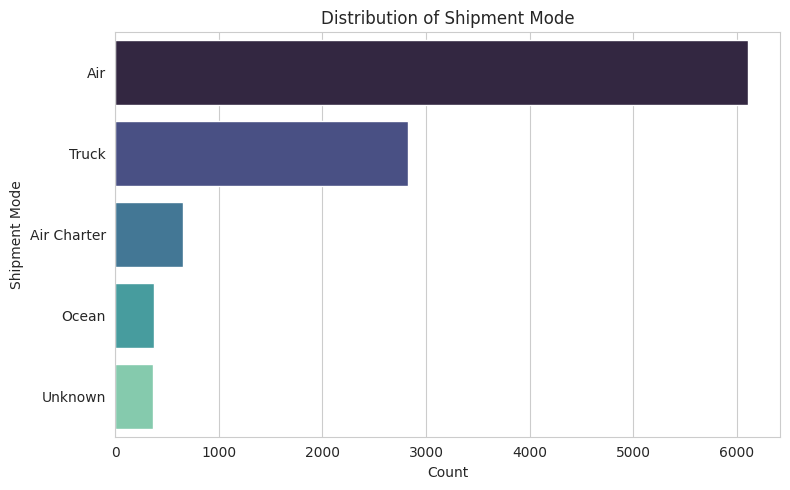

In [107]:
#Chart 2 — Shipment Mode Distribution
plt.figure(figsize=(8,5))
order = df['Shipment Mode'].value_counts().index
sns.countplot(y=df['Shipment Mode'], order=order, palette='mako')
plt.title('Distribution of Shipment Mode')
plt.xlabel('Count')
plt.ylabel('Shipment Mode')
plt.tight_layout()
plt.show()

**Why:** Shows which transport modes are used most.

**Insight:** Air dominates the dataset.

**Business Impact:** Heavy reliance on Air likely drives up overall freight cost , a key area to investigate for savings.

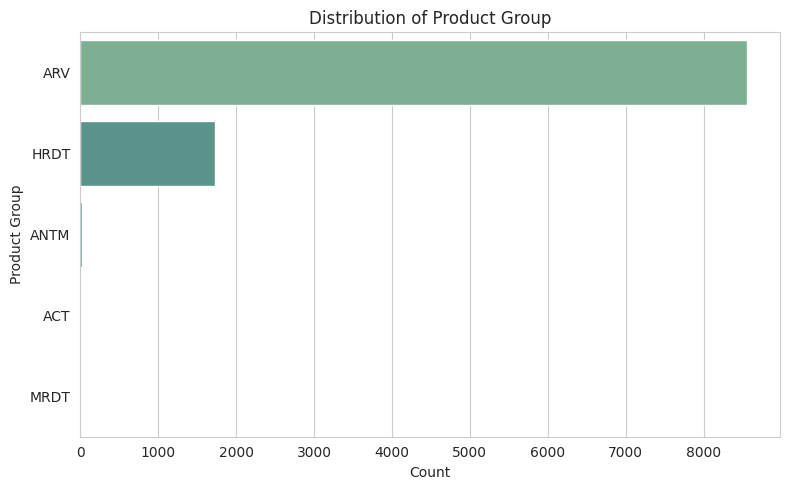

In [108]:
#Chart 3 — Product Group Distribution
plt.figure(figsize=(8,5))
order = df['Product Group'].value_counts().index
sns.countplot(y=df['Product Group'], order=order, palette='crest')
plt.title('Distribution of Product Group')
plt.xlabel('Count')
plt.ylabel('Product Group')
plt.tight_layout()
plt.show()

**Why:** Shows what's being shipped most often.

**Insight:** ARV drugs and HIV test kits make up most volume.

**Business Impact:** Any delay or cost issue affecting ARV shipments has an outsized impact on the whole business.

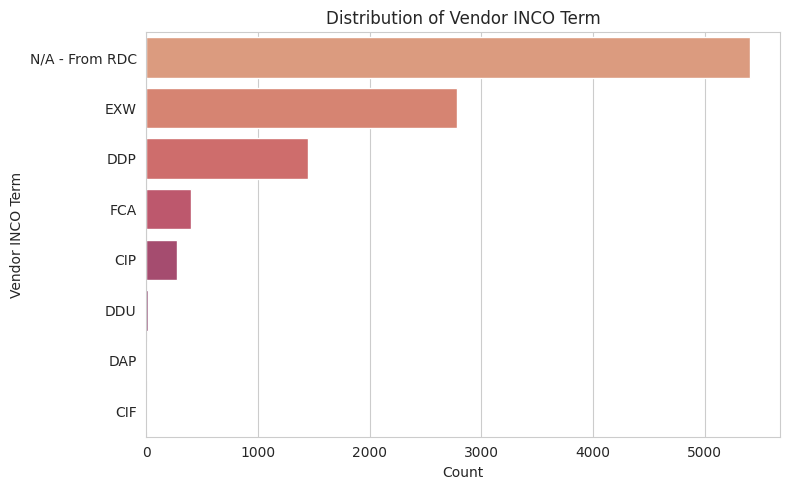

In [109]:
#Chart 4 — Vendor INCO Term Distribution
plt.figure(figsize=(8,5))
order = df['Vendor INCO Term'].value_counts().index
sns.countplot(y=df['Vendor INCO Term'], order=order, palette='flare')
plt.title('Distribution of Vendor INCO Term')
plt.xlabel('Count')
plt.ylabel('Vendor INCO Term')
plt.tight_layout()
plt.show()

**Why:** Shows which commercial shipping terms are most common.

**Insight:** EXW and DDP terms dominate, meaning FedEx/buyer takes on more shipping responsibility early.

**Business Impact:** Renegotiating terms with underperforming vendors could reduce FedEx's own logistics risk.

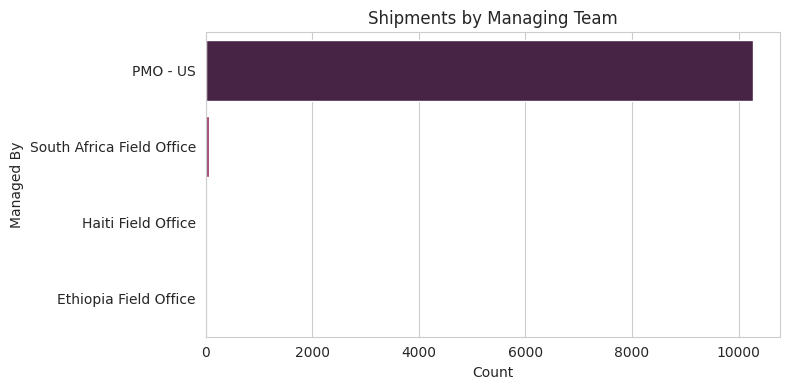

In [110]:
#Chart 5 — Managed By (Team) Distribution
plt.figure(figsize=(8,4))
order = df['Managed By'].value_counts().index
sns.countplot(y=df['Managed By'], order=order, palette='rocket')
plt.title('Shipments by Managing Team')
plt.xlabel('Count')
plt.ylabel('Managed By')
plt.tight_layout()
plt.show()

**Why:** Shows which internal team manages the most shipments.

**Insight:** PMO - US manages almost all shipments; other field offices handle very little.

**Business Impact:** PMO - US's processes set the company-wide performance baseline — its efficiency matters most.

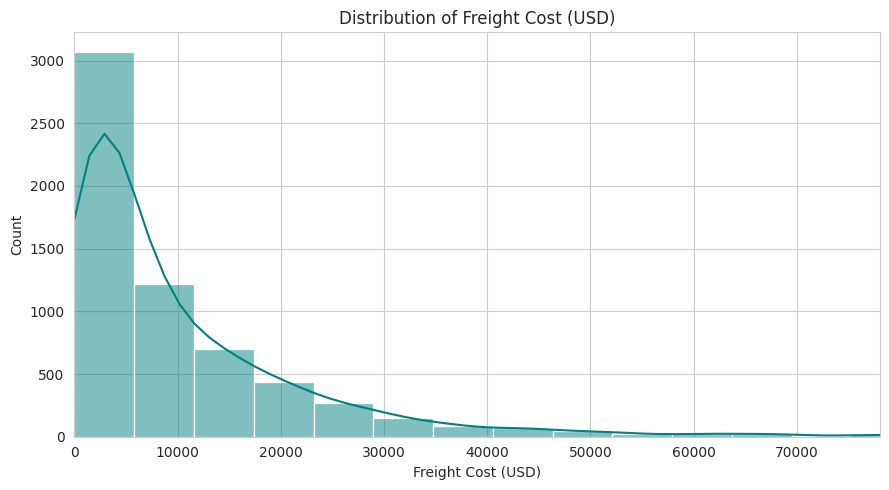

In [111]:
#Chart 6 — Distribution of Freight Cost (USD)
plt.figure(figsize=(9,5))
sns.histplot(df['Freight Cost (USD)'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Freight Cost (USD)')
plt.xlabel('Freight Cost (USD)')
plt.xlim(0, df['Freight Cost (USD)'].quantile(0.99))
plt.tight_layout()
plt.show()

**Why:** Histogram shows the spread of shipping costs.

**Insight:** Freight cost is right-skewed — most shipments are cheap, a few are very expensive.

**Business Impact:** High-cost outlier shipments deserve individual audit — they may be avoidable "rush" charges.

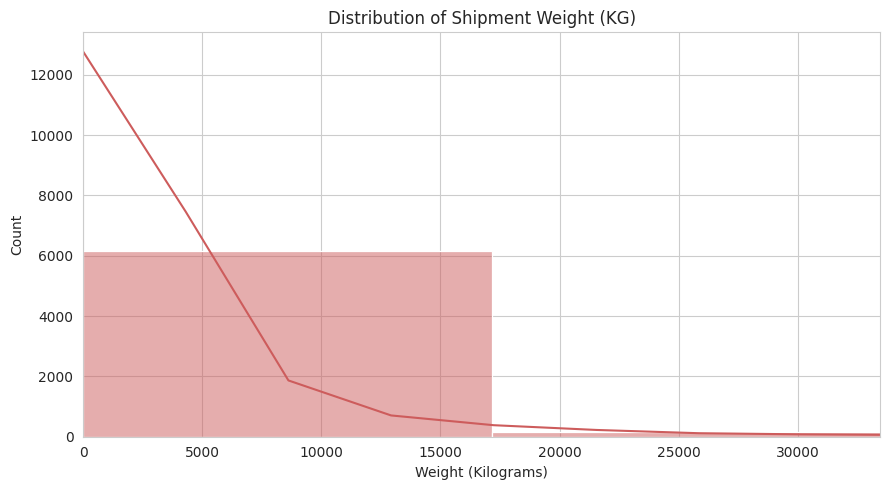

In [112]:
#Chart 7 — Distribution of Weight (Kilograms)
plt.figure(figsize=(9,5))
sns.histplot(df['Weight (Kilograms)'].dropna(), bins=50, kde=True, color='indianred')
plt.title('Distribution of Shipment Weight (KG)')
plt.xlabel('Weight (Kilograms)')
plt.xlim(0, df['Weight (Kilograms)'].quantile(0.99))
plt.tight_layout()
plt.show()

**Why:** Histogram shows typical shipment size.

**Insight:** Weight is right-skewed — most shipments are light, a few are bulk/heavy.

**Business Impact:** Heavy shipments are good candidates for switching to cheaper Ocean/Truck freight.

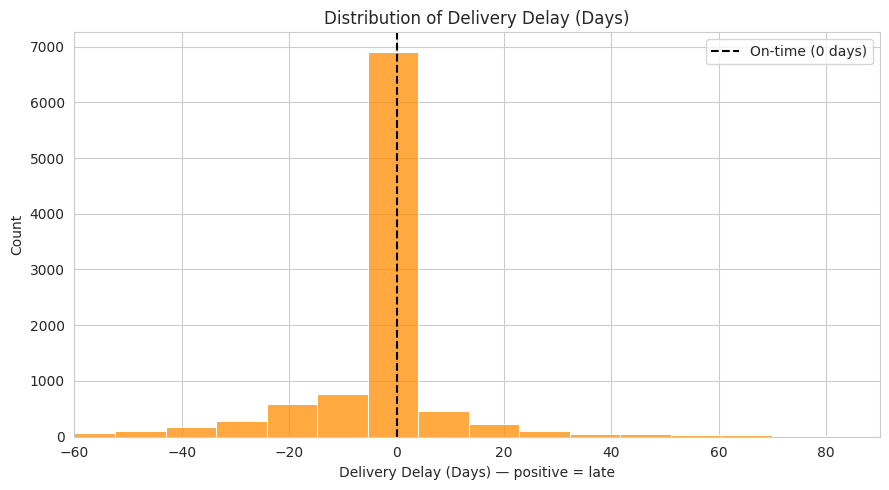

In [113]:
#Chart 8 — Distribution of Delivery Delay (Days)
plt.figure(figsize=(9,5))
sns.histplot(df['Delivery Delay (Days)'].dropna(), bins=60, kde=False, color='darkorange')
plt.axvline(0, color='black', linestyle='--', label='On-time (0 days)')
plt.title('Distribution of Delivery Delay (Days)')
plt.xlabel('Delivery Delay (Days) — positive = late')
plt.xlim(-60, 90)
plt.legend()
plt.tight_layout()
plt.show()

**Why:** Histogram shows how well FedEx meets scheduled delivery dates overall.

**Insight:** Most shipments are close to on-time, but there's a long tail of very late deliveries.

**Business Impact:** The late-delivery tail is where root-cause investigation will have the highest value.

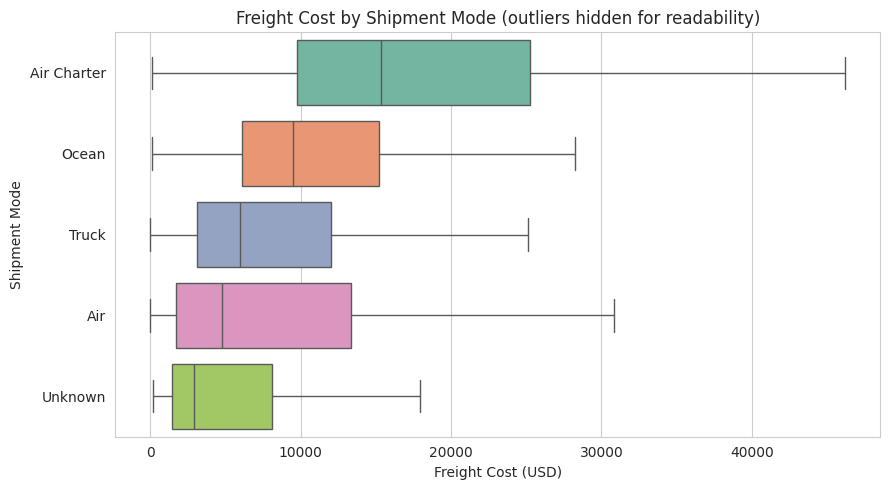

In [114]:
#Chart 9 — Freight Cost by Shipment Mode
plt.figure(figsize=(9,5))
order = df.groupby('Shipment Mode')['Freight Cost (USD)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Freight Cost (USD)', y='Shipment Mode', order=order, palette='Set2', showfliers=False)
plt.title('Freight Cost by Shipment Mode (outliers hidden for readability)')
plt.xlabel('Freight Cost (USD)')
plt.tight_layout()
plt.show()

**Why:** Boxplot compares cost distribution across shipment modes.

**Insight:** Air and Air Charter cost noticeably more than Truck/Ocean.

**Business Impact:** Confirms Air as the main cost driver — shifting non-urgent Air shipments to cheaper modes saves money.

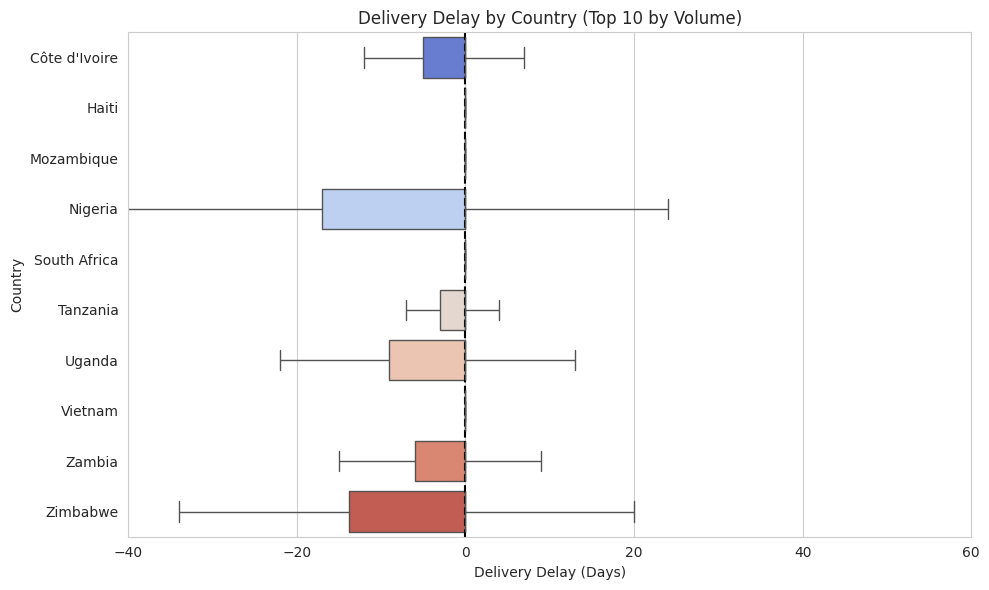

In [115]:
#Chart 10 — Delivery Delay by Top 10 Countries
top10 = df['Country'].value_counts().nlargest(10).index
subset = df[df['Country'].isin(top10)]

plt.figure(figsize=(10,6))
order = subset.groupby('Country')['Delivery Delay (Days)'].median().sort_values(ascending=False).index
sns.boxplot(data=subset, x='Delivery Delay (Days)', y='Country', order=order, palette='coolwarm', showfliers=False)
plt.axvline(0, color='black', linestyle='--')
plt.title('Delivery Delay by Country (Top 10 by Volume)')
plt.xlabel('Delivery Delay (Days)')
plt.xlim(-40, 60)
plt.tight_layout()
plt.show()

**Why:** Boxplot compares delay spread across top countries.

**Insight:** Delay patterns vary by country — some show consistently higher delays.

**Business Impact:** High-delay countries likely have structural issues (customs, infrastructure) needing targeted fixes.

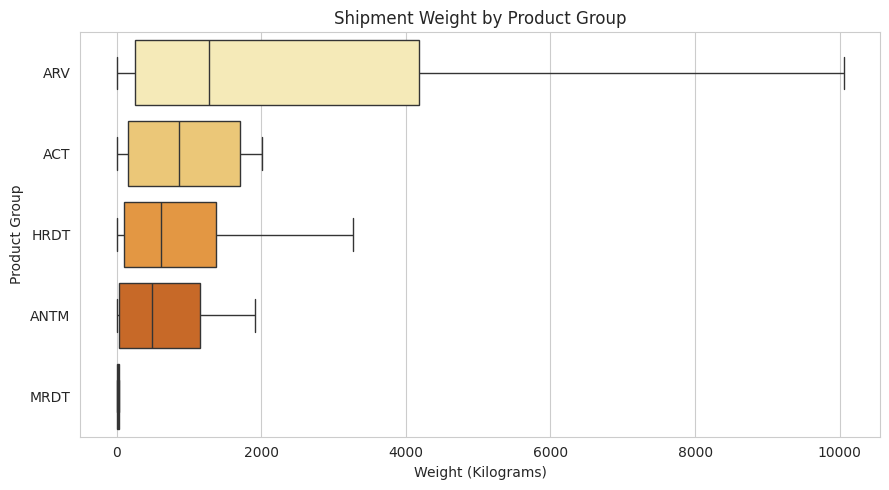

In [116]:
#Chart 11 — Weight by Product Group
plt.figure(figsize=(9,5))
order = df.groupby('Product Group')['Weight (Kilograms)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Weight (Kilograms)', y='Product Group', order=order, palette='YlOrBr', showfliers=False)
plt.title('Shipment Weight by Product Group')
plt.xlabel('Weight (Kilograms)')
plt.tight_layout()
plt.show()

**Why:** Boxplot shows which product types are heavier.

**Insight:** ARV shipments are heavier than HIV test kits.

**Business Impact:** ARV is both high-volume and high-weight — the top target for bulk ocean-freight contracts.

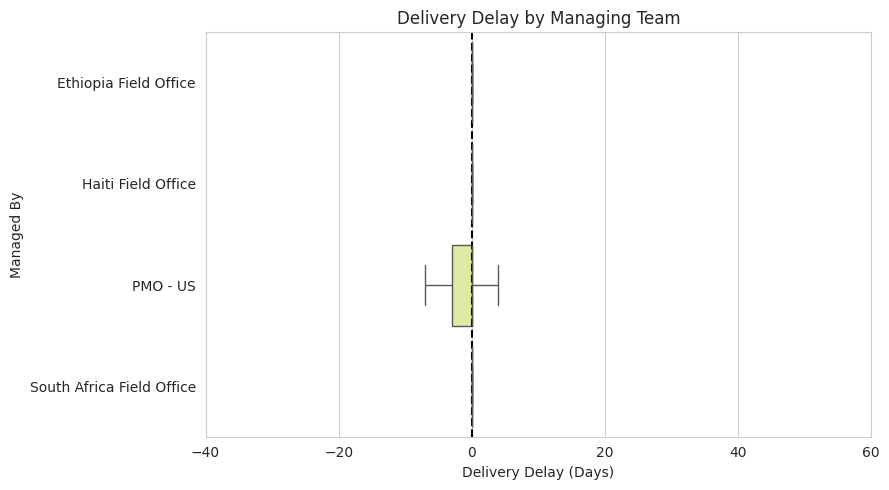

In [117]:
#Chart 12 — Delivery Delay by Managing Team (Research Question)
plt.figure(figsize=(9,5))
order = df.groupby('Managed By')['Delivery Delay (Days)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Delivery Delay (Days)', y='Managed By', order=order, palette='Spectral', showfliers=False)
plt.axvline(0, color='black', linestyle='--')
plt.title('Delivery Delay by Managing Team')
plt.xlabel('Delivery Delay (Days)')
plt.xlim(-40, 60)
plt.tight_layout()
plt.show()

**Why:** Boxplot compares delay performance across teams.

**Insight:** Delay distributions differ by managing team.

**Business Impact:** The best-performing team's process is worth studying and replicating elsewhere.

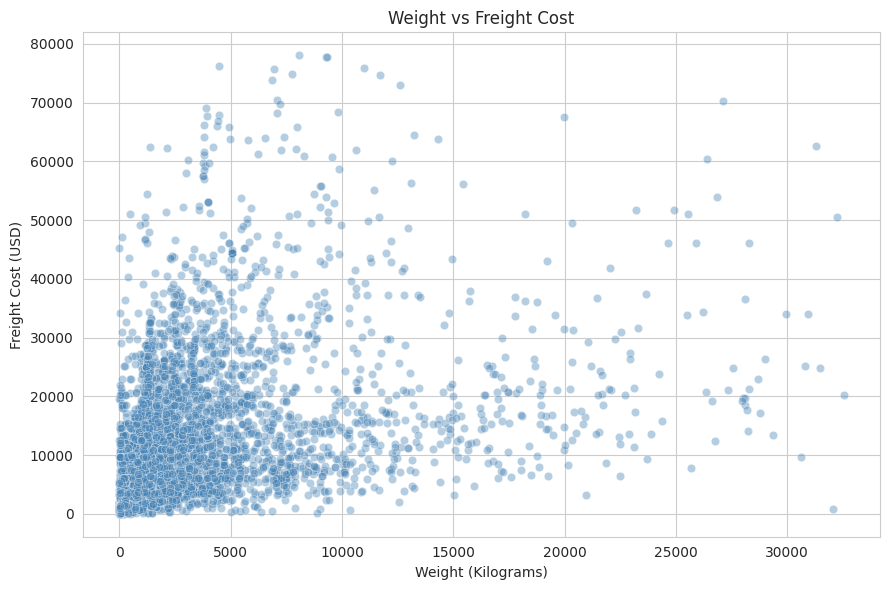

In [118]:
#Chart 13 — Weight vs Freight Cost
plt.figure(figsize=(9,6))
sample = df.dropna(subset=['Weight (Kilograms)', 'Freight Cost (USD)'])
sample = sample[(sample['Weight (Kilograms)'] < sample['Weight (Kilograms)'].quantile(0.99)) &
                 (sample['Freight Cost (USD)'] < sample['Freight Cost (USD)'].quantile(0.99))]
sns.scatterplot(data=sample, x='Weight (Kilograms)', y='Freight Cost (USD)', alpha=0.4, color='steelblue')
plt.title('Weight vs Freight Cost')
plt.tight_layout()
plt.show()

**Why:** Scatter plot checks if heavier shipments cost proportionally more.

**Insight:** Positive relationship exists, but with a lot of spread.

**Business Impact:** Shipment mode/route matters as much as weight — cost optimization needs both levers.

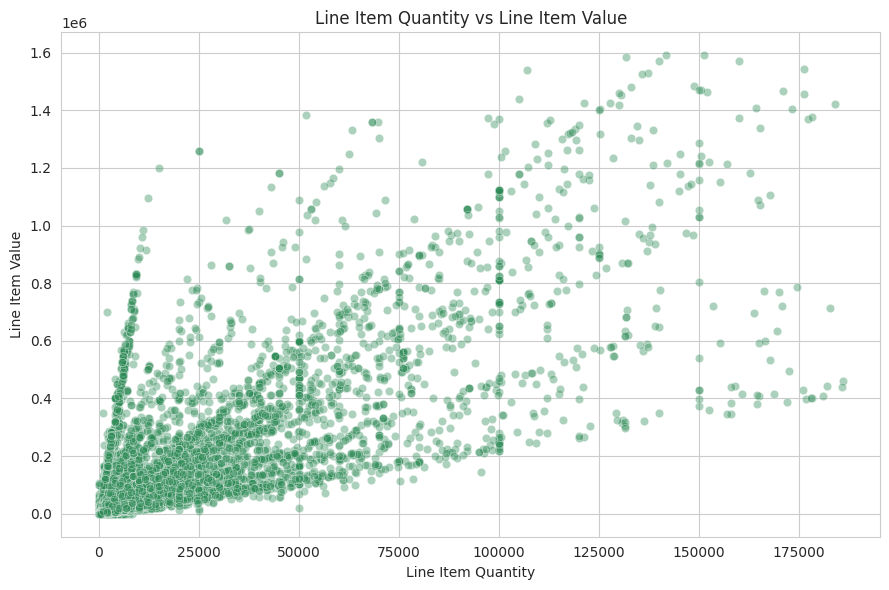

In [119]:
#Chart 14 — Line Item Quantity vs Line Item Value
plt.figure(figsize=(9,6))
sample2 = df.dropna(subset=['Line Item Quantity', 'Line Item Value'])
sample2 = sample2[(sample2['Line Item Quantity'] < sample2['Line Item Quantity'].quantile(0.99)) &
                   (sample2['Line Item Value'] < sample2['Line Item Value'].quantile(0.99))]
sns.scatterplot(data=sample2, x='Line Item Quantity', y='Line Item Value', alpha=0.4, color='seagreen')
plt.title('Line Item Quantity vs Line Item Value')
plt.tight_layout()
plt.show()

**Why:** Scatter plot checks if order value scales with quantity.

**Insight:** Value increases with quantity but in distinct "bands," suggesting different unit prices.

**Business Impact:** Worth benchmarking unit prices across vendors for similar order sizes.

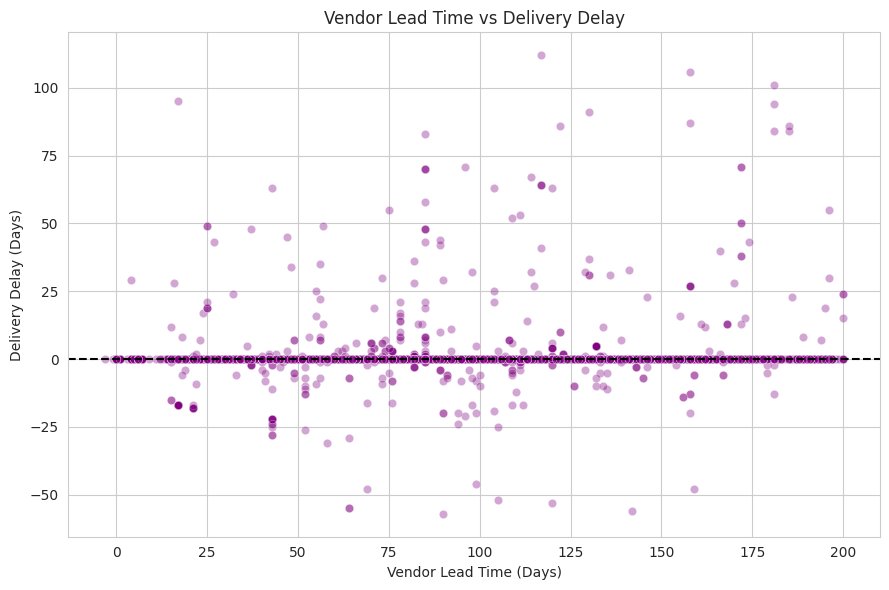

In [120]:
#Chart 15 — Vendor Lead Time vs Delivery Delay (Research Question)
plt.figure(figsize=(9,6))
sample3 = df.dropna(subset=['Vendor Lead Time (Days)', 'Delivery Delay (Days)'])
sample3 = sample3[(sample3['Vendor Lead Time (Days)'].between(-10, 200)) &
                   (sample3['Delivery Delay (Days)'].between(-60, 120))]
sns.scatterplot(data=sample3, x='Vendor Lead Time (Days)', y='Delivery Delay (Days)', alpha=0.35, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Vendor Lead Time vs Delivery Delay')
plt.tight_layout()
plt.show()

**Why:** Scatter plot tests if longer planning time reduces delay.

**Insight:** Very short lead times show a wider spread of delays.

**Business Impact:** Enforcing a minimum vendor lead time could reduce delay risk.

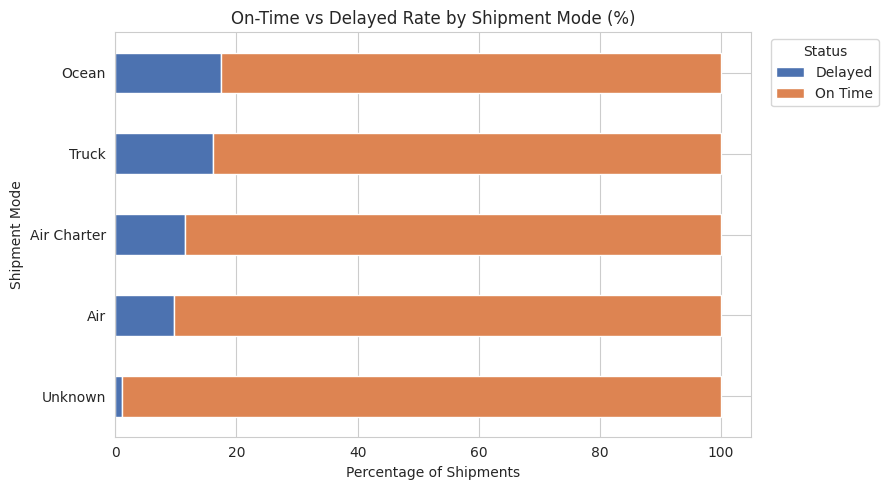

In [121]:
#Chart 16 — Shipment Mode vs On-Time Status (Research Question)
ct = pd.crosstab(df['Shipment Mode'], df['On Time Status'], normalize='index') * 100
ct = ct.sort_values('On Time', ascending=False)

ct.plot(kind='barh', stacked=True, figsize=(9,5), color=['#4C72B0', '#DD8452'])
plt.title('On-Time vs Delayed Rate by Shipment Mode (%)')
plt.xlabel('Percentage of Shipments')
plt.ylabel('Shipment Mode')
plt.legend(title='Status', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Why:** Stacked bar compares on-time rate across shipment modes.

**Insight:** Faster modes (Air) don't automatically mean better on-time rate.

**Business Impact:** A slower/cheaper mode with a similar or better on-time rate is a clear win-win switch.

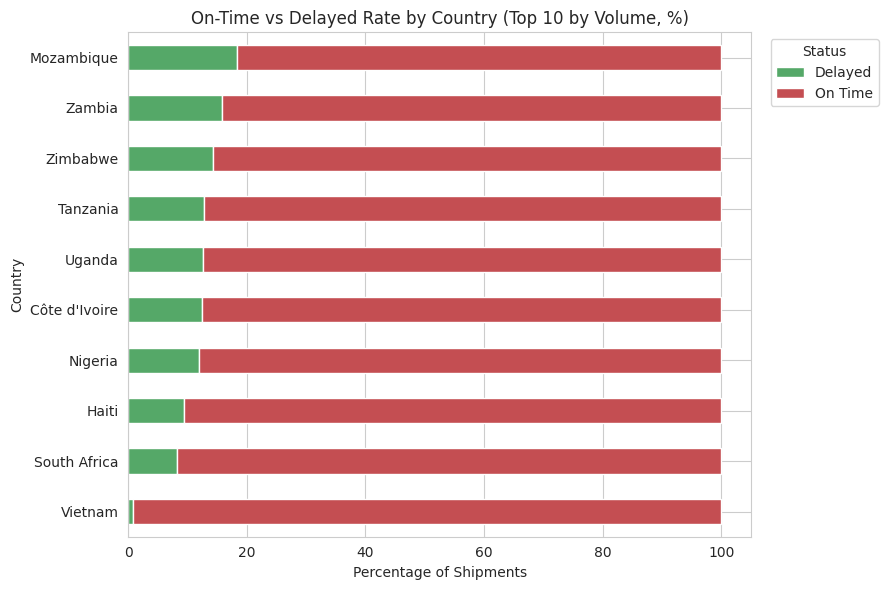

In [122]:
#Chart 17 — On-Time Rate by Top 10 Countries (Research Question)
ct2 = pd.crosstab(subset['Country'], subset['On Time Status'], normalize='index') * 100
ct2 = ct2.sort_values('On Time', ascending=False)

ct2.plot(kind='barh', stacked=True, figsize=(9,6), color=['#55A868', '#C44E52'])
plt.title('On-Time vs Delayed Rate by Country (Top 10 by Volume, %)')
plt.xlabel('Percentage of Shipments')
plt.ylabel('Country')
plt.legend(title='Status', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Why:** Stacked bar compares on-time rate across top countries.

**Insight:** On-time % varies a lot by country.

**Business Impact:** Low-performing, high-volume countries should be flagged for supply chain review.

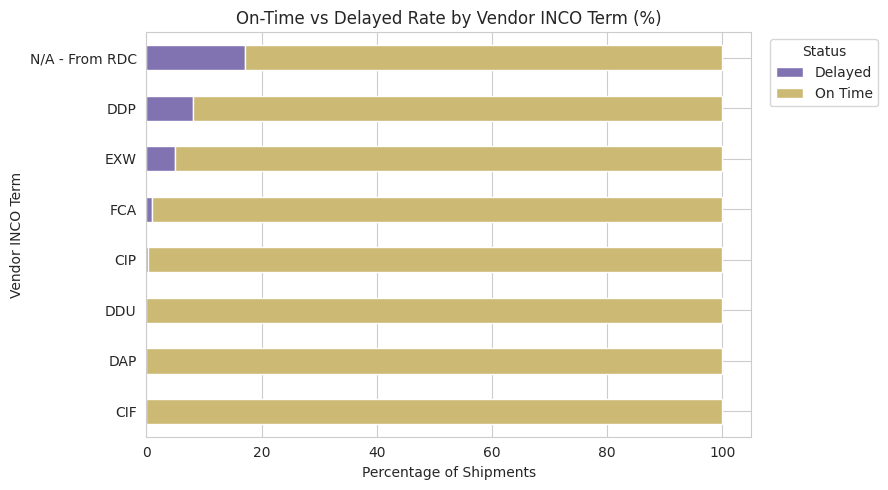

In [123]:
#Chart 18 — Vendor INCO Term vs On-Time Status (Research Question)
ct3 = pd.crosstab(df['Vendor INCO Term'], df['On Time Status'], normalize='index') * 100
ct3 = ct3.sort_values('On Time', ascending=False)

ct3.plot(kind='barh', stacked=True, figsize=(9,5), color=['#8172B2', '#CCB974'])
plt.title('On-Time vs Delayed Rate by Vendor INCO Term (%)')
plt.xlabel('Percentage of Shipments')
plt.ylabel('Vendor INCO Term')
plt.legend(title='Status', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Why:** Stacked bar compares on-time rate across INCO terms.

**Insight:** On-time performance differs depending on the commercial term used.

**Business Impact:** Supports renegotiating terms with vendors whose terms show poor on-time performance.

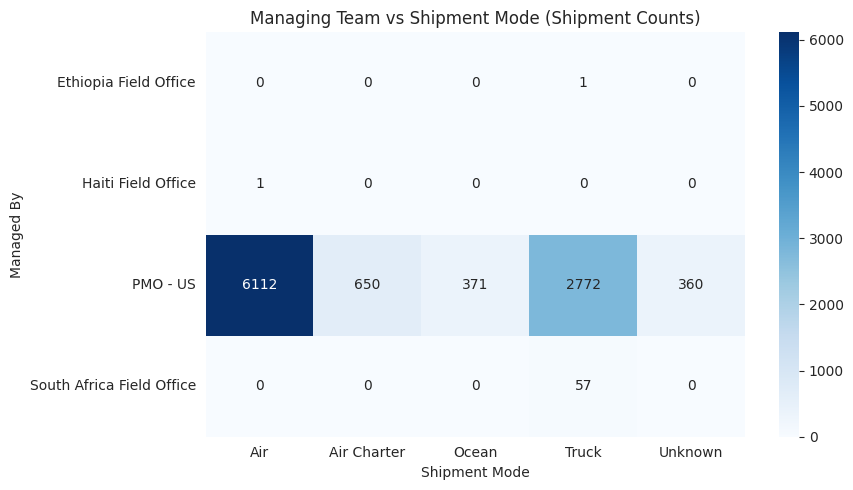

In [124]:
#Chart 19 — Managing Team vs Shipment Mode (Heatmap)
pivot = pd.crosstab(df['Managed By'], df['Shipment Mode'])

plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title('Managing Team vs Shipment Mode (Shipment Counts)')
plt.tight_layout()
plt.show()

**Why:** Heatmap shows how teams and shipment modes relate.

**Insight:** PMO - US relies heavily on Air compared to other teams.

**Business Impact:** Shifting even part of PMO - US's Air volume to cheaper modes would create the largest company-wide savings.

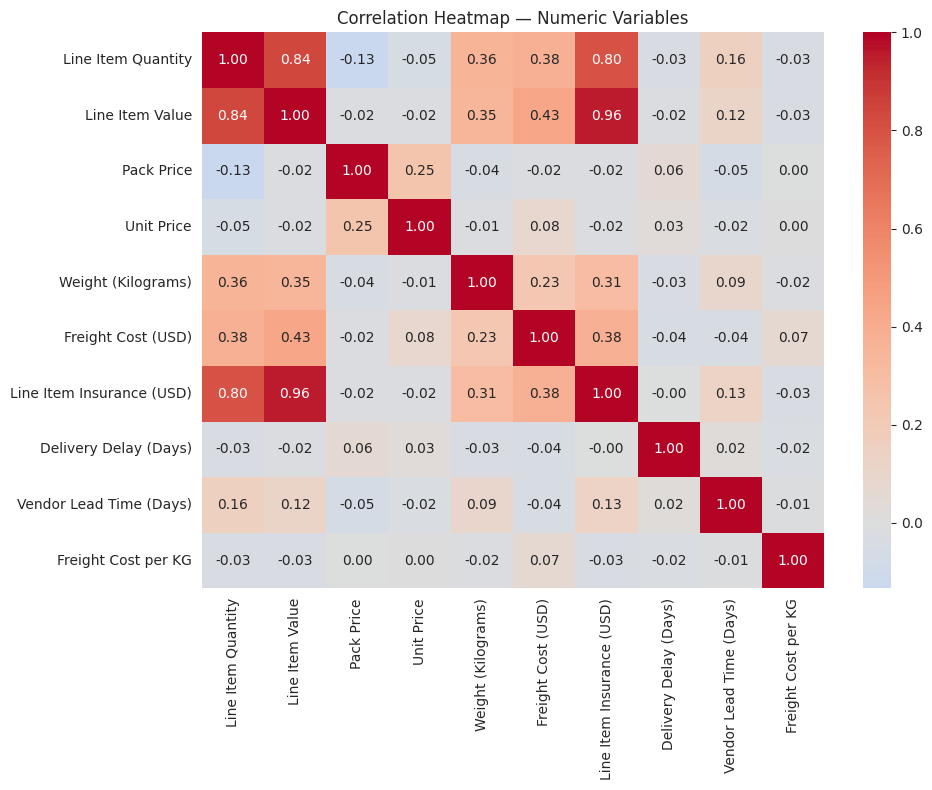

In [125]:
#Chart 20 — Correlation Heatmap of Numeric Variables
numeric_cols = ['Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price',
                 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)',
                 'Delivery Delay (Days)', 'Vendor Lead Time (Days)', 'Freight Cost per KG']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Variables')
plt.tight_layout()
plt.show()

**Why:** Heatmap shows how all numeric variables relate to each other.

**Insight:** Freight Cost correlates strongly with Weight/Insurance but weakly with Delay.

**Business Impact:** Cost and delivery reliability are separate problems needing separate fixes.

In [126]:
#Chart 21 — Freight Cost vs Weight, Colored by Shipment Mode (Interactive)
sample4 = df.dropna(subset=['Weight (Kilograms)', 'Freight Cost (USD)', 'Shipment Mode'])
sample4 = sample4[(sample4['Weight (Kilograms)'] < sample4['Weight (Kilograms)'].quantile(0.98)) &
                   (sample4['Freight Cost (USD)'] < sample4['Freight Cost (USD)'].quantile(0.98))]

fig = px.scatter(sample4, x='Weight (Kilograms)', y='Freight Cost (USD)', color='Shipment Mode',
                  opacity=0.5, title='Freight Cost vs Weight by Shipment Mode',
                  hover_data=['Country', 'Vendor'])
fig.update_layout(height=550)
fig.show()

**Why:** Adds shipment mode as a third dimension to the cost-weight relationship.

**Insight:** Air has a steeper cost-per-kg slope than Ocean/Truck.

**Business Impact:** Quantifies exactly how much could be saved by shifting heavy Air shipments to cheaper modes.

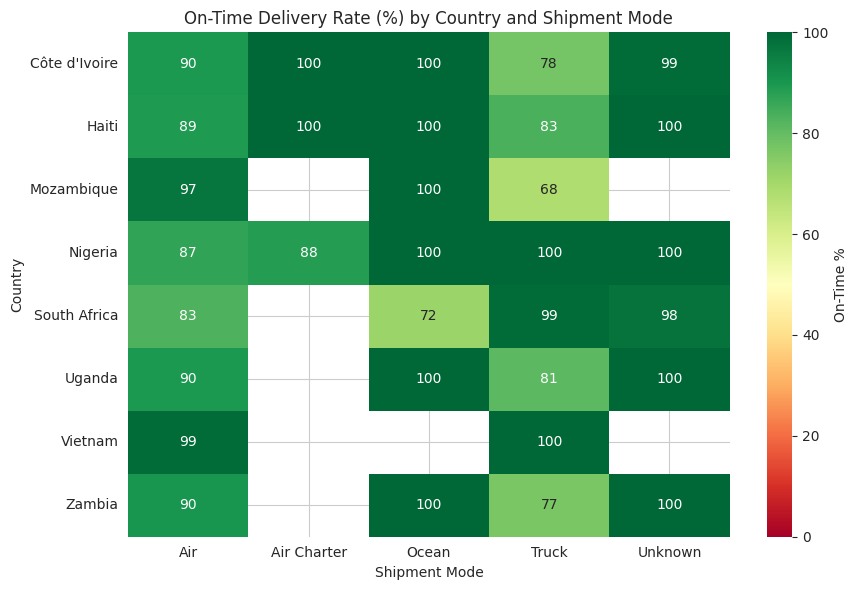

In [127]:
#Chart 22 — On-Time Rate by Country and Shipment Mode (Heatmap)
top8_countries = df['Country'].value_counts().nlargest(8).index
sub = df[df['Country'].isin(top8_countries)].copy()
sub['On Time Numeric'] = (sub['On Time Status'] == 'On Time').astype(int)

pivot2 = sub.pivot_table(index='Country', columns='Shipment Mode', values='On Time Numeric', aggfunc='mean') * 100

plt.figure(figsize=(9,6))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, cbar_kws={'label': 'On-Time %'})
plt.title('On-Time Delivery Rate (%) by Country and Shipment Mode')
plt.tight_layout()
plt.show()

**Why:** Combines country, mode, and on-time rate in one view.

**Insight:** Some country-mode combinations underperform even when that mode is strong elsewhere.

**Business Impact:** Pinpoints exact routes needing local intervention (customs, last-mile logistics).

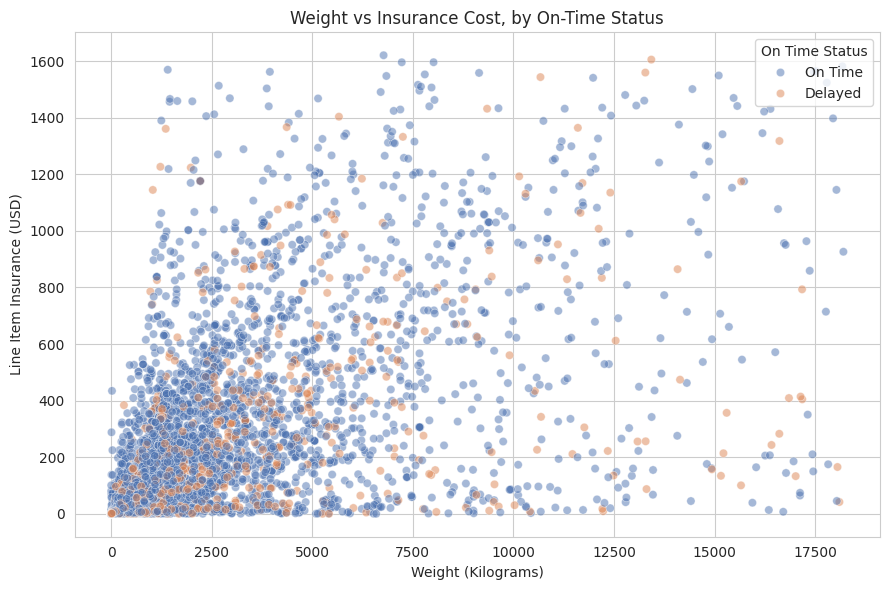

In [128]:
#Chart 23 — Weight vs Insurance Cost, Colored by On-Time Status
sample5 = df.dropna(subset=['Weight (Kilograms)', 'Line Item Insurance (USD)'])
sample5 = sample5[(sample5['Weight (Kilograms)'] < sample5['Weight (Kilograms)'].quantile(0.97)) &
                   (sample5['Line Item Insurance (USD)'] < sample5['Line Item Insurance (USD)'].quantile(0.97)) &
                   (sample5['Line Item Insurance (USD)'] > 0)]

plt.figure(figsize=(9,6))
sns.scatterplot(data=sample5, x='Weight (Kilograms)', y='Line Item Insurance (USD)',
                 hue='On Time Status', alpha=0.5, palette={'On Time':'#4C72B0', 'Delayed':'#DD8452'})
plt.title('Weight vs Insurance Cost, by On-Time Status')
plt.tight_layout()
plt.show()


**Why:** Checks if higher-weight/insurance shipments are more delay-prone.

**Insight:** Insurance rises with weight, but on-time vs delayed shipments look similar across this relationship.

**Business Impact:** Insurance cost isn't a useful delay predictor — delay needs to be tackled through other levers.

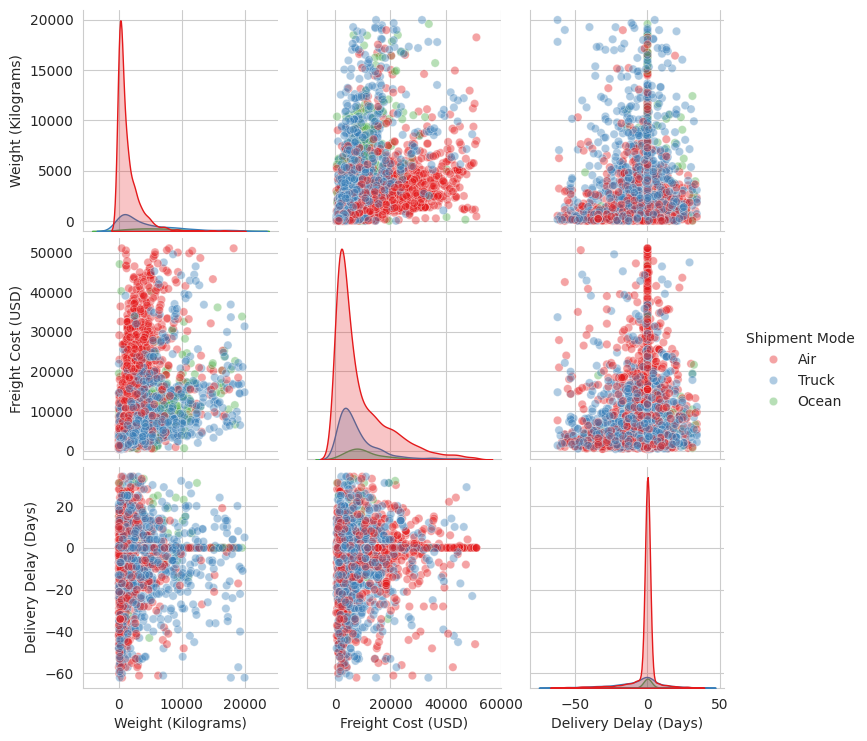

In [129]:
#chart 24 — Pairplot of Key Variables by Shipment Mode
pair_cols = ['Weight (Kilograms)', 'Freight Cost (USD)', 'Delivery Delay (Days)', 'Shipment Mode']
pair_df = df[pair_cols].dropna()
pair_df = pair_df[pair_df['Shipment Mode'].isin(['Air', 'Ocean', 'Truck'])]

for c in ['Weight (Kilograms)', 'Freight Cost (USD)', 'Delivery Delay (Days)']:
    q99 = pair_df[c].quantile(0.98)
    q01 = pair_df[c].quantile(0.02)
    pair_df = pair_df[(pair_df[c] <= q99) & (pair_df[c] >= q01)]

sns.pairplot(pair_df, hue='Shipment Mode', palette='Set1', diag_kind='kde', plot_kws={'alpha':0.4})
plt.show()

**Why:** Summarizes weight, cost, and delay relationships across modes in one view.

**Insight:** Air clusters at higher cost for a given weight; delay overlaps across all modes.

**Business Impact:** Confirms cost-optimization and reliability-optimization need separate strategies.